In [1]:
import importlib
import logging
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

logging.basicConfig()
logging.getLogger().setLevel(logging.INFO)

from datetime import datetime
from portfolio_optimization import *
import numpy as np

# S&P and Dow Jones Tickers
sp_dj_asset_tickers = {
    "SPY": "U.S. Equities",                     # SPDR S&P 500 ETF Trust                     
    "SPDW": "International Equities",           # SPDR Portfolio Developed World ex-US ETF
    "SPEM": "Emerging Market Equities",         # SPDR Portfolio Emerging Markets ETF
    "RWX": "Real Estate",                       # SPDR Dow Jones International Real Estate ETF (RWX)
    "^SPGSCI": "Commodities",                     # Dow Jones Commodity Index
    "LQD": "Investment-Grade Bonds",            # S&P 500 Bond Index
    "SPHY": "High-Yield Bonds",                 # SPDR Portfolio High Yield Bond ETF
    "BWX": "International Sovereign Bonds"      # SPDR Bloomberg International Treasury Bond ETF
}


trading_days_in_year = 252
# Define the start and end dates for fetching the data
start_date = '1998-01-01'
end_date = datetime.today().strftime("%Y-%m-%d")

In [2]:
!pip install pandas yfinance matplotlib seaborn -q

In [43]:
tickers = dict(sp_dj_asset_tickers)

returns_df = download_tickers_returns(tickers=tickers, start_date="1998-12-23", cache_path="../data/historical-asset-classes-returns.csv")
returns_df.tail()

,U.S. Equities,International Equities,Emerging Market Equities,Real Estate,Commodities,Investment-Grade Bonds,High-Yield Bonds,International Sovereign Bonds
Date,,,,,,,,
2024-08-12,0.000525,0.000288,0.004544,-0.008554,0.017986,0.002096,0.000428,0.000884
2024-08-13,0.016446,0.016710,0.008781,0.019216,-0.013446,0.007004,0.004274,0.004857
2024-08-14,0.003155,0.003117,-0.004748,0.002309,-0.004702,0.004426,0.001277,0.000879
2024-08-15,0.017140,0.012994,0.010867,0.001152,0.008600,-0.003058,0.001700,-0.007024
2024-08-16,0.002242,0.005577,0.009701,0.001917,-0.011766,0.002977,0.002970,0.006631


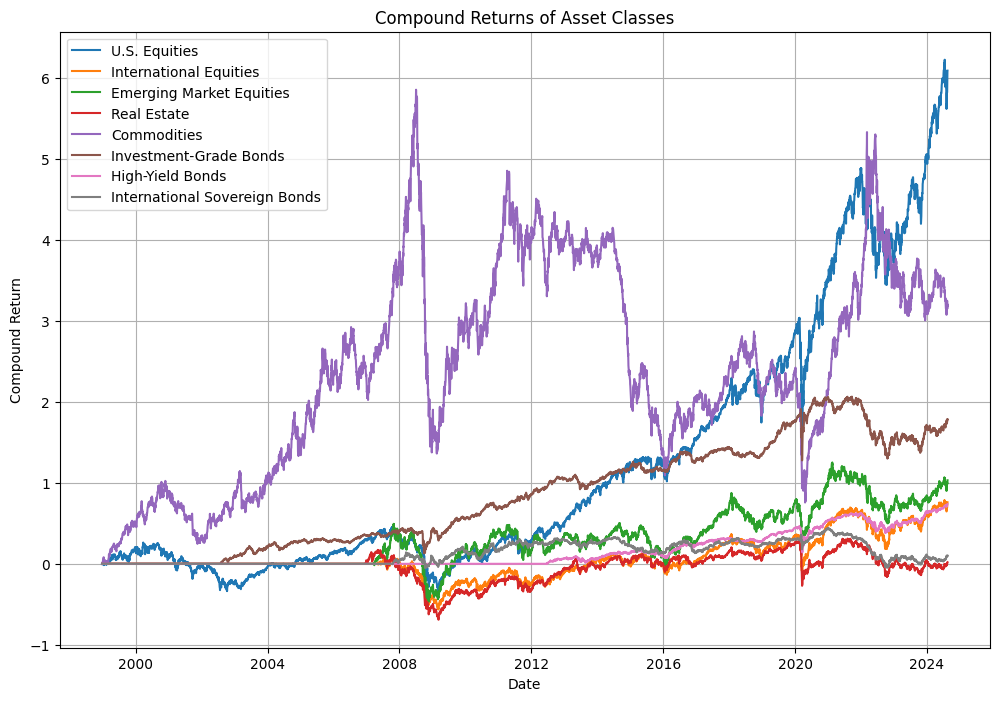

In [44]:
# Calculate compound returns
compound_returns = (1 + returns_df).cumprod() - 1

# Plot the compound returns
plt.figure(figsize=(12, 8))
for column in compound_returns.columns:
    plt.plot(compound_returns.index, compound_returns[column], label=column)

plt.title('Compound Returns of Asset Classes')
plt.ylabel('Compound Return')
plt.xlabel('Date')
plt.legend()
plt.grid(True)
plt.show()

differentiates between upside and downside volatility. The Sortino Ratio considers only downside volatility when assessing risk.

In [16]:
frequency = 'daily'
annual_factor = annualized_factor_from_freq[frequency]
recent_returns_df = returns_df.iloc[-1095:]

# Get mean returns and covariance matrix
expected_returns = annualized_expected_return(returns=recent_returns_df)
cov_matrix = recent_returns_df.cov() * annual_factor

In [48]:

# weights_parity = portfolio_optimization(cov_matrix=cov_matrix, goal='riskParity')
# print(weights_parity)
# calculate_risk_contribution(w=weights_parity, V=cov_matrix)
max_sharpe_objective = MaxSharpeRatio(returns_df=None, 
                                      expected_returns=expected_returns, cov_matrix=cov_matrix, risk_free_rate=0.01)
w = portfolio_optimization(objective=max_sharpe_objective, max_exposure=0.3)
w

array([3.00000000e-01, 1.00000000e-01, 4.03819803e-17, 0.00000000e+00,
       3.00000000e-01, 0.00000000e+00, 3.00000000e-01, 0.00000000e+00])

In [56]:
import importlib
imported_module = importlib.import_module("portfolio_optimization")
importlib.reload(imported_module)
from portfolio_optimization import *

sortino_ratio(returns=recent_returns_df, risk_free_rate=0.01, frequency='daily')

U.S. Equities                    28.304095
International Equities           18.266516
Emerging Market Equities         14.590147
Real Estate                       4.317892
Commodities                      27.175794
Investment-Grade Bonds           -1.815487
High-Yield Bonds                  8.029581
International Sovereign Bonds    -5.430498
dtype: float64

In [90]:
frequency = 'daily'
annual_factor = annualized_factor_from_freq[frequency]
# Get mean returns and covariance matrix
expected_returns = annualized_expected_return(returns=recent_returns_df)
vol_returns = returns_df.std() * np.sqrt(annual_factor)
cov_matrix = returns_df.cov() * annual_factor
sharpe_ratio(expected_return=expected_returns, volatility_return=risk_free_rate=0.01)

TypeError: sharpe_ratio() missing 1 required positional argument: 'volatility_return'

In [76]:
import importlib
imported_module = importlib.import_module("portfolio_optimization")
importlib.reload(imported_module)
from portfolio_optimization import *

max_sortino_objective = MaxSortinoRatio(returns_df=recent_returns_df)
w = portfolio_optimization(objective=max_sortino_objective)
w

array([7.10910501e-01, 0.00000000e+00, 0.00000000e+00, 2.54446590e-13,
       2.89089499e-01, 0.00000000e+00, 0.00000000e+00, 1.17200601e-13])

In [82]:
sharpe_portfolio_returns, sharpe_weights = calculate_historical_portfolio_allocation(returns=returns_df,
                                                                                     objective_class=MaxSharpeRatio,
                                                                                     frequency='daily')

/home/alan/Quantropy/src/portfolio_optimization.py:632: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  


Error in optimization for date 2006-12-31 00:00:00: Optimization did not converge


/home/alan/Quantropy/src/portfolio_optimization.py:632: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  


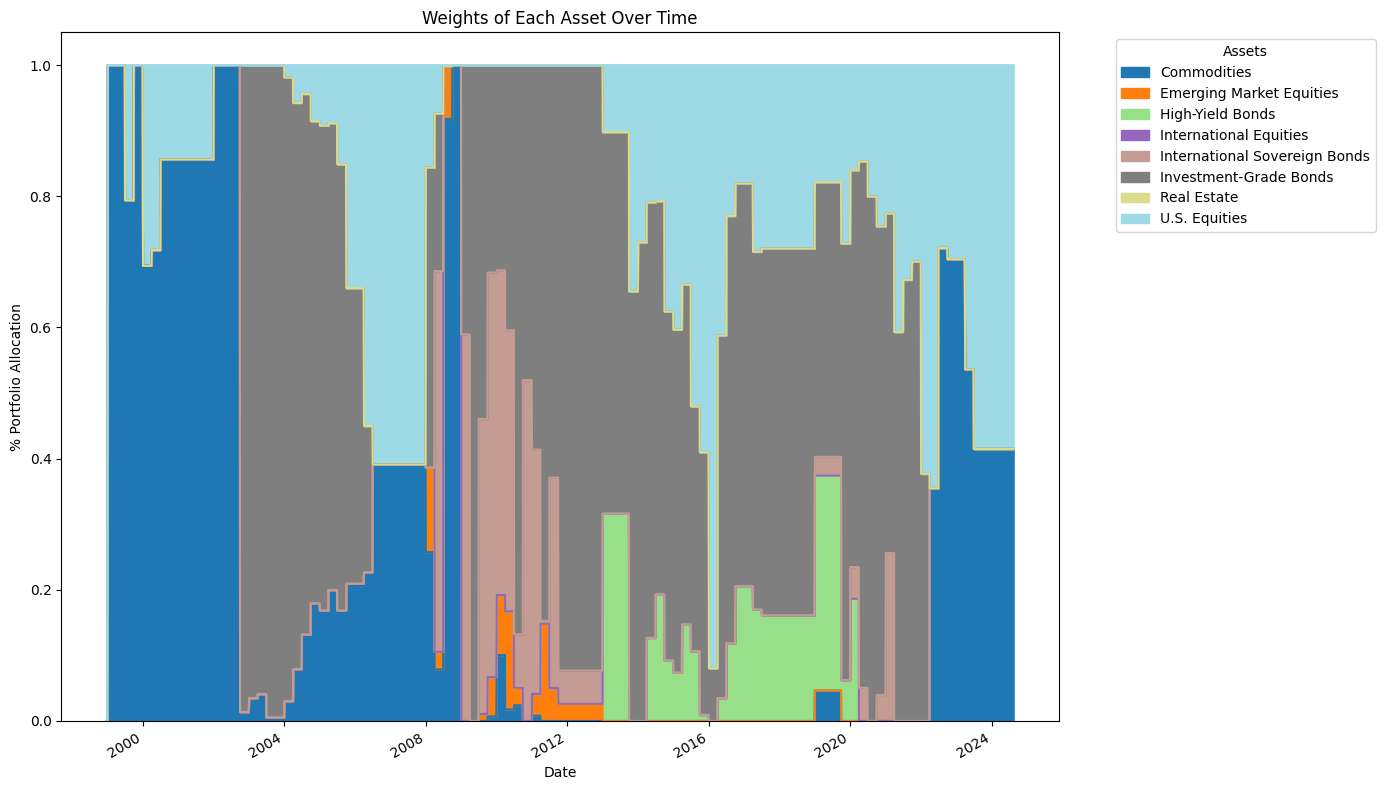

In [83]:
sortino_portfolio_returns, sortino_weights = calculate_historical_portfolio_allocation(returns=returns_df,
                                                                                     objective_class=MaxSortinoRatio,
                                                                                     frequency='daily')
plot_weight_allocations(weights=sortino_weights)

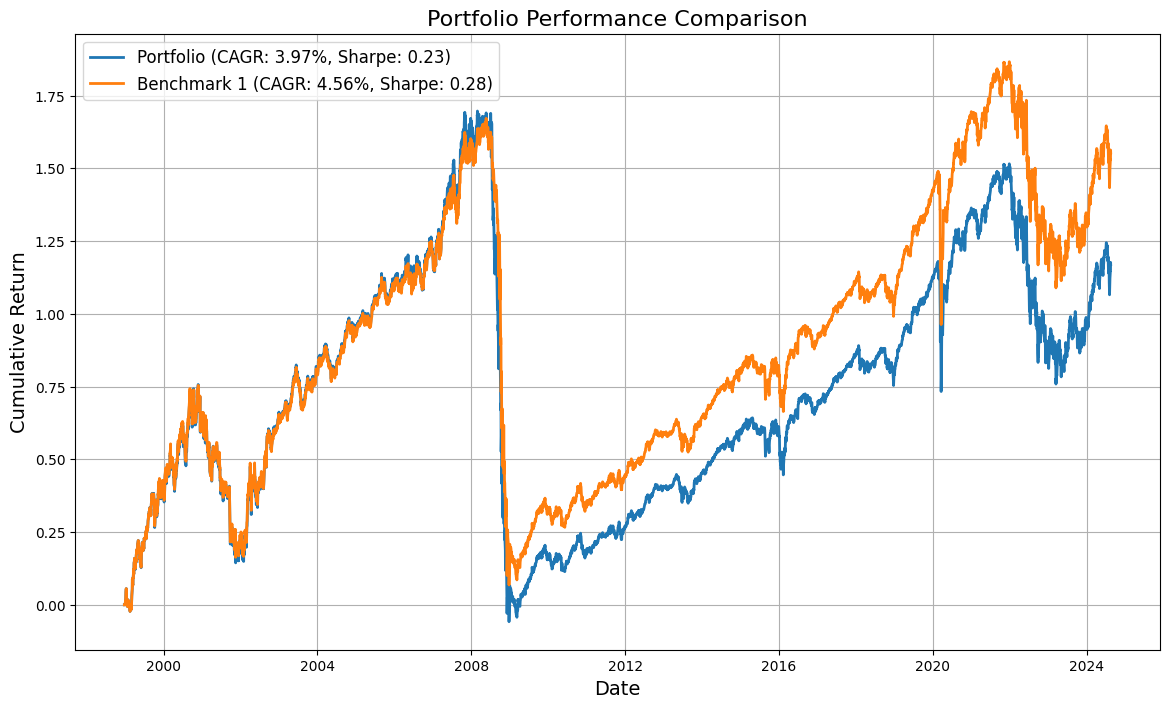

In [85]:
sharpe_returns_df = sharpe_portfolio_returns.to_frame(name="Max Sharpe Portfolio")
sortino_returns_df = sortino_portfolio_returns.to_frame(name="Max Sortino Portfolio")
portf_and_bench_returns = sharpe_returns_df.join(sortino_returns_df)

# Plot the performance
plot_portfolio_performance(portfolio_returns=portf_and_bench_returns["Max Sortino Portfolio"],
                           benchmark_returns=portf_and_bench_returns["Max Sharpe Portfolio"])


Current Recommendation

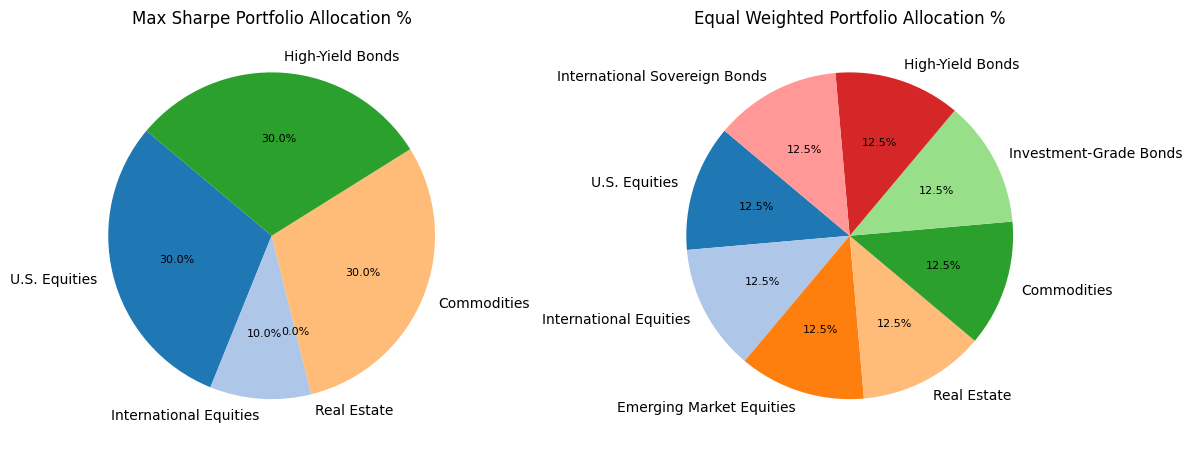

In [21]:
plot_piecharts(items=[sharpe_weights.iloc[-1], eq_weights.iloc[-1]], 
               titles=("Max Sharpe Portfolio Allocation %", "Equal Weighted Portfolio Allocation %"))

Our portfolio seemed to have given a better return, for a lower volatility, hence giving a higher Sharpe ratio.
Note: some abus de language
* Sharpe Ratio includes a risk-free rate. haven't mentioned here to keep it one concept at a time. better use "risk-adjusted return' or 'return per unit of risk'

In [22]:
portfolio_performance(portfolio_returns=sharpe_portfolio_returns, frequency="daily")

,inception,1Y,3Y,5Y,10Y
annualized_return,0.070065,0.115747,0.009592,0.054745,0.055433
annualized_volatility,0.109744,0.079081,0.105746,0.107162,0.085499
sharpe_ratio,0.547323,1.337197,-0.003859,0.417546,0.531393


In [26]:
portfolio_performance(portfolio_returns=eq_portfolio_returns, frequency="daily")

,inception,1Y,3Y,5Y,10Y
annualized_return,0.067465,0.118292,0.006444,0.060939,0.042865
annualized_volatility,0.133809,0.083024,0.109140,0.128202,0.108932
sharpe_ratio,0.429455,1.304344,-0.032582,0.397332,0.301706


Modern Portfolio Theory is fundamentally sound, in the way that it computes portfolio volatility and returns given individual assets. However, given non-normally distributed assets:

Mean returns isn't necessarily a good proxy to Expected Returns (CLT, Law of Large Numbers). 

Portfolio volatiltiy isn't necessarily a good proxy to "Risk", and computing it using a standard covariance matrix contributes to the problem.

Overall risk is based on correlations; however, they are not static, but change over time...

Highly sensitive; can concentrate a big % to one asset, and nothing to others.

Highly dependent on timeframe (lookback period)



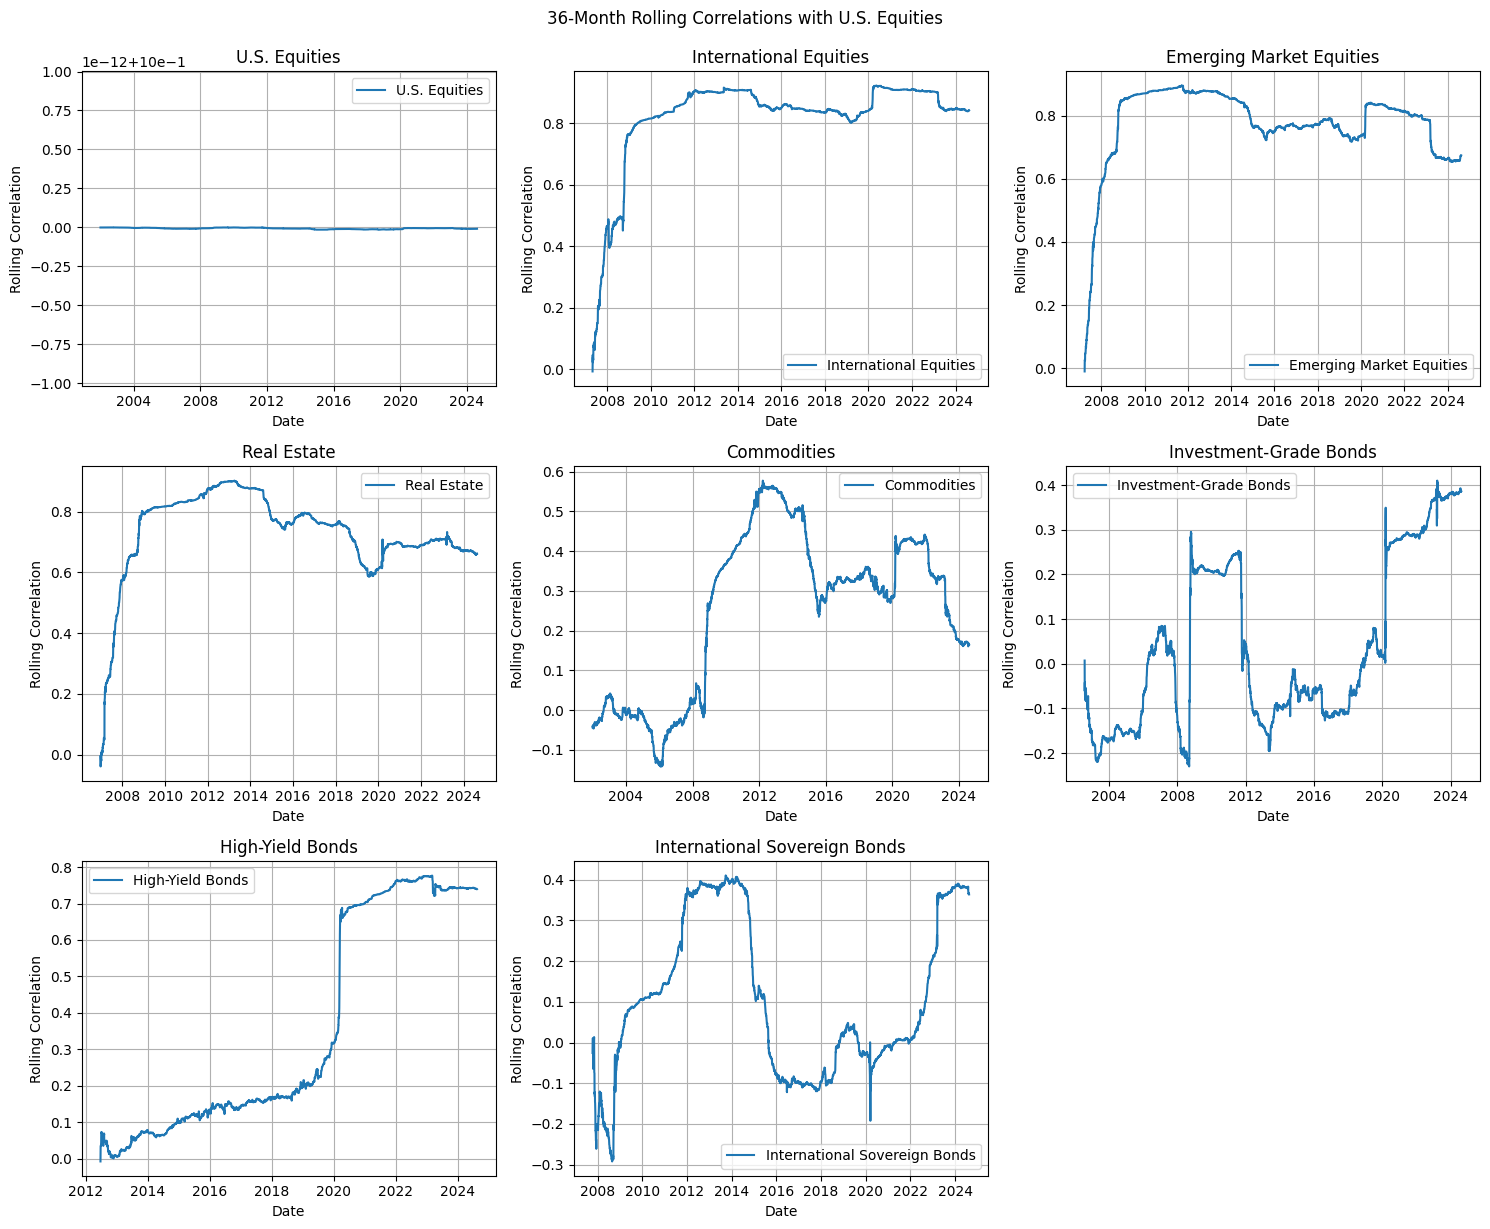

In [24]:
target_asset = 'U.S. Equities'  # Replace with your target asset class
comparison_assets = returns_df.columns  # Replace with your list of comparison asset classes
plot_rolling_correlations(returns_df, target_asset, comparison_assets, window_months=36)